In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
train_dir = "/content/drive/MyDrive/dataset/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/dataset/FruitinAmazon/test"
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2
seed = 123
epochs = 10

TASK 1: Data Inspection
No corrupted images found.


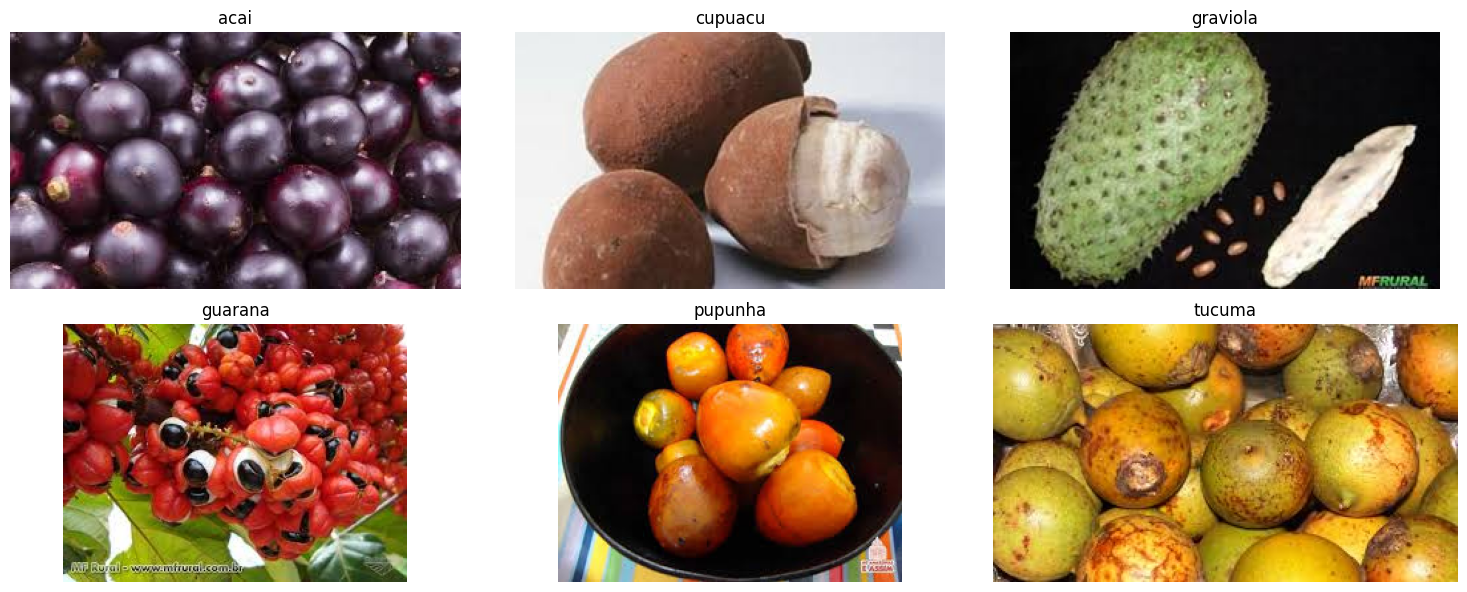

Observed 6 classes. Each folder contains images of that fruit.


In [5]:
import random

def check_corrupted_images(directory):
    """Check and remove corrupted images in the directory tree."""
    corrupted_count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except (IOError, SyntaxError, OSError):
                    print(f"Removed corrupted image: {file_path}")
                    os.remove(file_path)
                    corrupted_count += 1
    if corrupted_count == 0:
        print("No corrupted images found.")
    else:
        print(f"Removed {corrupted_count} corrupted images.")

def visualize_one_per_class(train_dir):
    """Display one image from each class in a grid."""
    classes = [d for d in os.listdir(train_dir)
               if os.path.isdir(os.path.join(train_dir, d))]
    classes.sort()
    num_classes = len(classes)

    fig, axes = plt.subplots(2, (num_classes + 1) // 2, figsize=(15, 6))
    axes = axes.flatten()

    for i, class_name in enumerate(classes):
        class_path = os.path.join(train_dir, class_name)
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            img_path = os.path.join(class_path, random.choice(images))
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(class_name)
            axes[i].axis('off')

    # Hide unused subplots
    for j in range(num_classes, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Observed {num_classes} classes. Each folder contains images of that fruit.")

# Run Task 1
print("=" * 50)
print("TASK 1: Data Inspection")
print("=" * 50)
check_corrupted_images(train_dir)
visualize_one_per_class(train_dir)

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

# Load test dataset (no shuffling, no validation split)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [7]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

# Normalize pixel values from [0,255] to [0,1]
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Optional: Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [8]:
# Infer number of classes from training directory
class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)
num_classes = len(class_names)

model = keras.Sequential([
    # Convolutional Block 1
    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional Block 2
    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Flatten and Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 537ms/step - accuracy: 0.1250 - loss: 2.6875 - val_accuracy: 0.1667 - val_loss: 2.3857
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 624ms/step - accuracy: 0.1806 - loss: 1.8464 - val_accuracy: 0.1667 - val_loss: 1.7037
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 728ms/step - accuracy: 0.2222 - loss: 1.6753 - val_accuracy: 0.6667 - val_loss: 1.5366
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 0.3889 - loss: 1.5982 - val_accuracy: 0.7222 - val_loss: 1.4699
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.3472 - loss: 1.4830 - val_accuracy: 0.6111 - val_loss: 1.3389
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 422ms/step - accuracy: 0.3472 - loss: 1.3540 - val_accuracy: 0.6111 - val_loss: 1.2563
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 0.3750 - loss: 1.2066 - val_accuracy: 0.6111 - val_loss: 1.3223
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 423ms/step - accuracy: 0.7500 - loss: 1.0719 - val_accuracy: 0.5000 - val_loss:

In [11]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix (optional)
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6000 - loss: 1.0995
Test Loss: 1.0995
Test Accuracy: 0.6000

Classification Report:
              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.50      0.80      0.62         5
    graviola       1.00      0.80      0.89         5
     guarana       1.00      0.20      0.33         5
     pupunha       0.56      1.00      0.71         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.54        30
weighted avg       0.60      0.60      0.54        30


Confusion Matrix:
[[4 1 0 0 0 0]
 [1 4 0 0 0 0]
 [0 1 4 0 0 0]
 [0 1 0 1 2 1]
 [0 0 0 0 5 0]
 [2 1 0 0 2 0]]


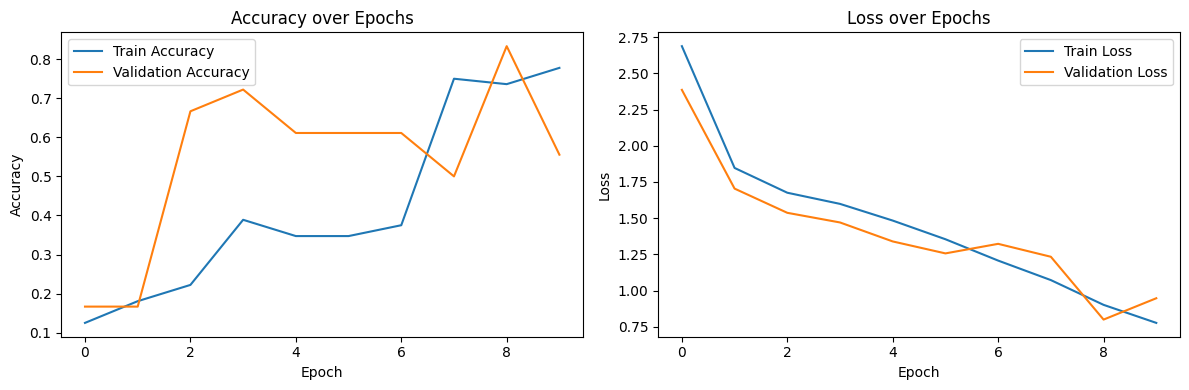

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.tight_layout()
plt.show()

In [13]:
model.save('fruit_classifier.h5')
print("Model saved as 'fruit_classifier.h5'")

# Optional: Load and test
loaded_model = keras.models.load_model('fruit_classifier.h5')
print("Model loaded successfully.")

Model saved as 'fruit_classifier.h5'
Model loaded successfully.
